<a href="https://colab.research.google.com/github/SofiaRekhman/Deep-Learning-Models/blob/master/Image_Classification_With_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
#!rm -r /content/dataset

In [15]:
# !apt-get update
# !apt-get install unrar-free
# !unrar x /content/dataset.rar /content/

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2

In [17]:
BASE_DIR = '/content/dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR = os.path.join(BASE_DIR, 'test')
TRAIN_CSV = os.path.join(BASE_DIR, 'train.csv')
TEST_CSV = os.path.join(BASE_DIR, 'test.csv')

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15

In [18]:
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

seed_everything(SEED)

In [19]:
df = pd.read_csv(TRAIN_CSV)
df['label'] = df['label'].astype(str)

def check_path(path):
    return os.path.exists(os.path.join(BASE_DIR, path))

df = df[df['path'].apply(check_path)]
print(f"Кількість валідних зображень: {len(df)}")

Кількість валідних зображень: 10796


In [20]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=df,
    directory=BASE_DIR,
    x_col='path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = train_datagen.flow_from_dataframe(
    dataframe=df,
    directory=BASE_DIR,
    x_col='path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

ACTUAL_NUM_CLASSES = len(train_gen.class_indices)
print(f"Кількість класів для моделі: {ACTUAL_NUM_CLASSES}")

Found 8637 validated image filenames belonging to 99 classes.
Found 2159 validated image filenames belonging to 99 classes.
Кількість класів для моделі: 99


In [21]:
def build_model(num_classes):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model(ACTUAL_NUM_CLASSES)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 99)             │        25,443 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611,363 (9.96 MB)

 Trainable params: 353,379 (1.35 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 168s 557ms/step - accuracy: 0.1419 - loss: 3.9301 - val_accuracy: 0.6674 - val_loss: 1.3915 - learning_rate: 0.0010
Epoch 2/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 124s 459ms/step - accuracy: 0.5513 - loss: 1.6923 - val_accuracy: 0.7749 - val_loss: 0.9024 - learning_rate: 0.0010
Epoch 3/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 125s 465ms/step - accuracy: 0.6612 - loss: 1.2299 - val_accuracy: 0.7920 - val_loss: 0.7729 - learning_rate: 0.0010
Epoch 4/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 124s 458ms/step - accuracy: 0.7093 - loss: 1.0392 - val_accuracy: 0.8249 - val_loss: 0.6621 - learning_rate: 0.0010
Epoch 5/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 123s 454ms/step - accuracy: 0.7403 - loss: 0.9054 - val_accuracy: 0.8282 - val_loss: 0.6387 - learning_rate: 0.0010
Epoch 6/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 124s 458ms/step - accuracy: 0.7710 - loss: 0.7957 - val_accuracy: 0.8504 - val_loss: 0.5657 - learning_rate: 0.0010
Epoch 7/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 123s 456ms/step - accura

In [24]:
#model.layers[1].trainable = True

base_model = model.layers[1]
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks_list
)

Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 164s 530ms/step - accuracy: 0.5959 - loss: 1.5565 - val_accuracy: 0.8675 - val_loss: 0.4726 - learning_rate: 1.0000e-05
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 125s 461ms/step - accuracy: 0.7436 - loss: 0.8627 - val_accuracy: 0.8648 - val_loss: 0.5011 - learning_rate: 1.0000e-05
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 125s 462ms/step - accuracy: 0.7787 - loss: 0.7261 - val_accuracy: 0.8615 - val_loss: 0.4803 - learning_rate: 1.0000e-05
Epoch 4/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 141s 524ms/step - accuracy: 0.7993 - loss: 0.6472 - val_accuracy: 0.8754 - val_loss: 0.4745 - learning_rate: 1.0000e-05
Epoch 5/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 125s 461ms/step - accuracy: 0.8219 - loss: 0.5993 - val_accuracy: 0.8698 - val_loss: 0.4950 - learning_rate: 2.0000e-06
Epoch 6/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 126s 467ms/step - accuracy: 0.8295 - loss: 0.5638 - val_accuracy: 0.8856 - val_loss: 0.4579 - learning_rate: 2.0000e-06
Epoch 7/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 

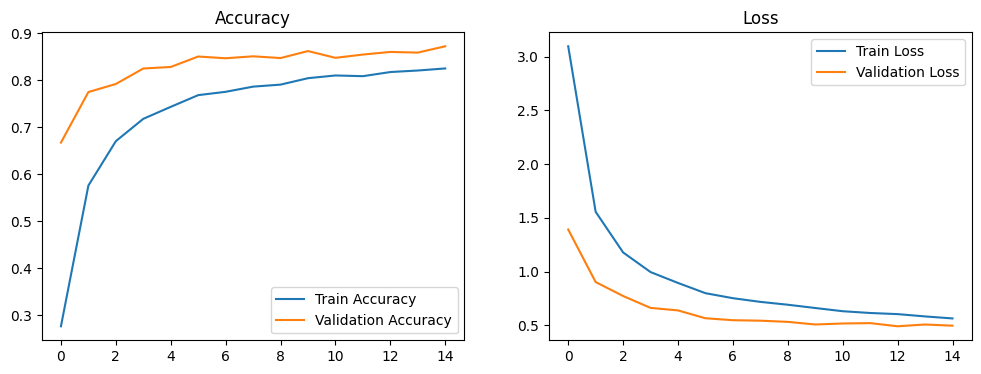

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [26]:
test_df = pd.read_csv(TEST_CSV)

def fix_path(path):
    path = str(path)
    return path if path.endswith('.jpg') else f"{path}.jpg"

if 'path' not in test_df.columns:
    test_df['path'] = test_df['id'].apply(fix_path)

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=BASE_DIR,
    x_col='path',
    y_col=None,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

predictions = model.predict(test_gen)
predicted_indices = np.argmax(predictions, axis=1)

labels_map = {v: k for k, v in train_gen.class_indices.items()}
predicted_labels = [labels_map[i] for i in predicted_indices]

submission = pd.DataFrame({'id': test_df['id'], 'label': predicted_labels})
submission.to_csv('submission.csv', index=False)

Found 2728 validated image filenames.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 176ms/step
